In [1]:
pip install pymupdf pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 19.4 MB/s eta 0:00:00


In [2]:
pip install pytesseract

In [ ]:
import pytesseract
!apt-get install tesseract-ocr -q

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import fitz
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from google.colab import drive

In [ ]:
from google.colab import files

uploaded = files.upload()

Page 1 — 1 accepted, 11 rejected


/tmp/ipykernel_4582/1942599040.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


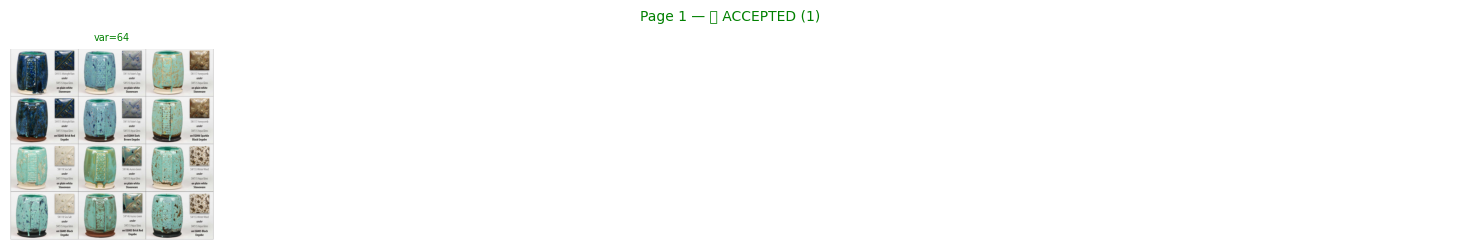

/tmp/ipykernel_4582/1942599040.py:94: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


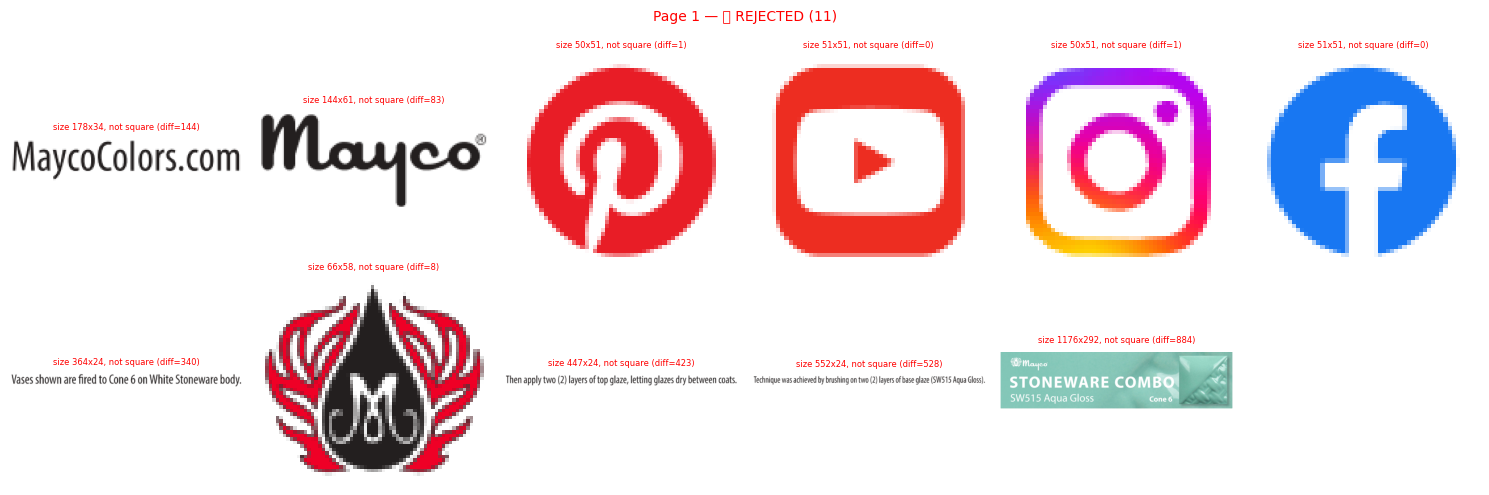

Page 2 — 1 accepted, 12 rejected


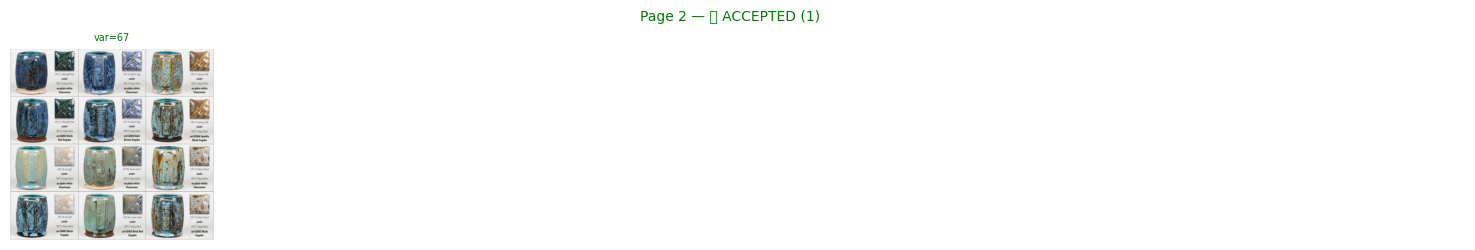

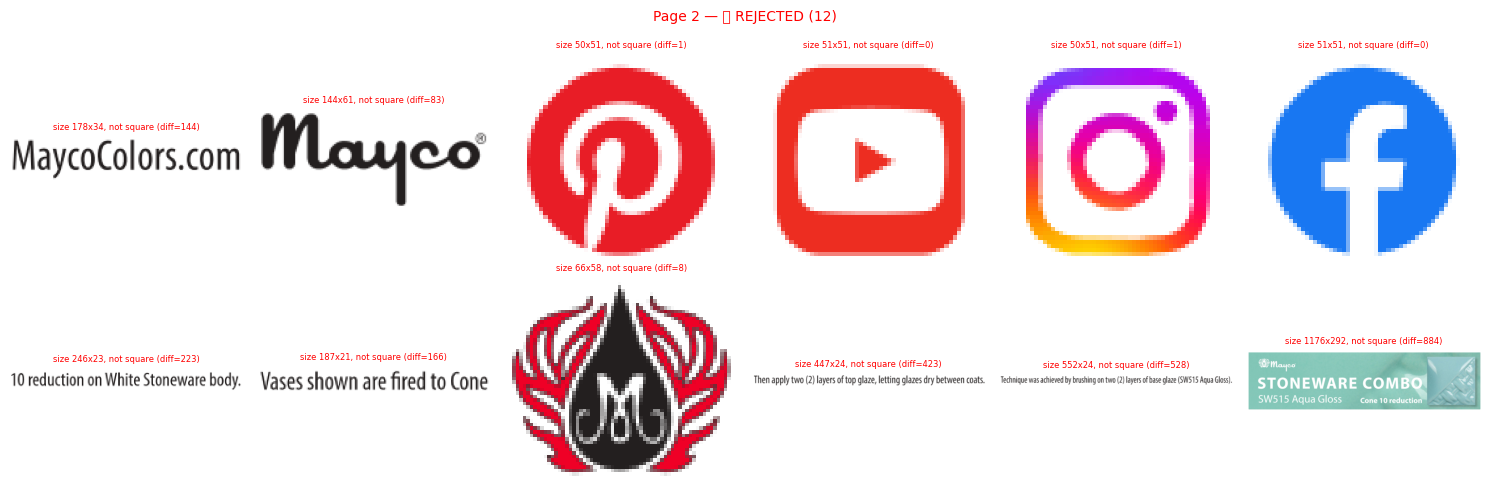

In [ ]:
uploaded_file = list(uploaded.keys())[0]
doc = fitz.open(uploaded_file)

VARIANCE_THRESHOLD = 21
MIN_SIZE = 1090
MAX_SIZE = 1200

def colour_variance(crop):
    return float(np.std(crop.astype(float)))

def overlap(a, b, threshold=0.5):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix = max(0, min(ax+aw, bx+bw) - max(ax, bx))
    iy = max(0, min(ay+ah, by+bh) - max(ay, by))
    inter = ix * iy
    smaller = min(aw * ah, bw * bh)
    return inter / smaller > threshold if smaller > 0 else False

def detect_swatches(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(blurred, 30, 100)
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    accepted = []
    rejected = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        if w < 20 or h < 20:
            continue

        crop = img_array[y:y+h, x:x+w]
        variance = colour_variance(crop)

        reasons = []
        if not (MIN_SIZE <= w <= MAX_SIZE and MIN_SIZE <= h <= MAX_SIZE):
            reasons.append(f"size {w}x{h}")
        if not (80 >= abs(w - h) >= 70): # changed:
            reasons.append(f"not square (diff={abs(w-h)})")
        if variance <= VARIANCE_THRESHOLD:
            reasons.append(f"flat var={variance:.0f}")

        if reasons:
            rejected.append((x, y, w, h, variance, ", ".join(reasons), crop))
        else:
            accepted.append((x, y, w, h, variance))

    filtered = []
    for c in sorted(accepted, key=lambda c: c[2]*c[3], reverse=True):
        if not any(overlap(c[:4], kept[:4]) for kept in filtered):
            filtered.append(c)

    return sorted(filtered, key=lambda c: (c[1], c[0])), rejected

for page_number, page in enumerate(doc, start=1):
    pix = page.get_pixmap(dpi=150)
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)

    accepted, rejected = detect_swatches(img_array)
    print(f"Page {page_number} — {len(accepted)} accepted, {len(rejected)} rejected")

    if accepted:
        cols = 6
        rows = -(-len(accepted) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance) in enumerate(accepted):
            axes[i].imshow(img_array[y:y+h, x:x+w])
            axes[i].axis("off")
            axes[i].set_title(f"var={variance:.0f}", fontsize=7, color="green")
        for j in range(len(accepted), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ✅ ACCEPTED ({len(accepted)})", fontsize=10, color="green")
        plt.tight_layout()
        plt.show()

    if rejected:
        cols = 6
        rows = -(-len(rejected) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance, reason, crop) in enumerate(rejected):
            axes[i].imshow(crop)
            axes[i].axis("off")
            axes[i].set_title(f"{reason}", fontsize=6, color="red")
        for j in range(len(rejected), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ❌ REJECTED ({len(rejected)})", fontsize=10, color="red")
        plt.tight_layout()
        plt.show()

In [ ]:
# ================================
# CONFIG
# ================================
GRID_ROWS = 4
GRID_COLS = 3

# ================================
# STAGE 2 — SPLIT ACCEPTED GRIDS INTO CELLS
# ================================

all_cells = []  # stores (page_number, grid_idx, cell_num, img_array)

for page_number, page in enumerate(doc, start=1):
    pix = page.get_pixmap(dpi=150)
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)

    accepted, _ = detect_swatches(img_array)
    print(f"Page {page_number} — {len(accepted)} grid(s) found")

    for grid_idx, (x, y, w, h, variance) in enumerate(accepted):
        grid_crop = img_array[y:y+h, x:x+w]
        gh, gw = grid_crop.shape[:2]

        cell_h = gh // GRID_ROWS
        cell_w = gw // GRID_COLS

        fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(GRID_COLS * 3, GRID_ROWS * 3))

        for row in range(GRID_ROWS):
            for col in range(GRID_COLS):
                y1, y2 = row * cell_h, (row + 1) * cell_h
                x1, x2 = col * cell_w, (col + 1) * cell_w

                cell = grid_crop[y1:y2, x1:x2]
                cell_num = row * GRID_COLS + col + 1

                all_cells.append((page_number, grid_idx, cell_num, cell))

                axes[row, col].imshow(cell)
                axes[row, col].set_title(f"S{cell_num:02d}", fontsize=8)
                axes[row, col].axis("off")

        plt.suptitle(f"Page {page_number} — Grid {grid_idx} split into {GRID_ROWS}x{GRID_COLS}")
        plt.tight_layout()
        plt.show()

print(f"\nTotal cells: {len(all_cells)}")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ================================
# STAGE 3 — CROP TOP RIGHT FOR SWATCH + BOTTOM FOR OCR
# ================================


SWATCH_TOP    = 0.01
SWATCH_BOTTOM = 0.48
SWATCH_LEFT   = 0.54
SWATCH_RIGHT  = 1.0

# Bottom text region
TEXT_TOP    = 0.45
TEXT_BOTTOM = 0.60
TEXT_LEFT   = 0.65
TEXT_RIGHT  = 0.95

def detect_swatches_in_cell(img_array):
    cell_h, cell_w = img_array.shape[:2]

    MIN_SIZE = 110
    MAX_SIZE = 125

    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(blurred, 30, 100)
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    accepted = []
    rejected = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < 20 or h < 20:
            continue

        crop = img_array[y:y+h, x:x+w]
        variance = colour_variance(crop)

        reasons = []
        if not (MIN_SIZE <= w <= MAX_SIZE and MIN_SIZE <= h <= MAX_SIZE):
            reasons.append(f"size {w}x{h}")
        if abs(w - h) > 10:
            reasons.append(f"not square (diff={abs(w-h)})")
        if variance <= VARIANCE_THRESHOLD:
            reasons.append(f"flat var={variance:.0f}")

        if reasons:
            rejected.append((x, y, w, h, variance, ", ".join(reasons), crop))
        else:
            accepted.append((x, y, w, h, variance))

    filtered = []
    for c in sorted(accepted, key=lambda c: c[2]*c[3], reverse=True):
        if not any(overlap(c[:4], kept[:4]) for kept in filtered):
            filtered.append(c)

    return sorted(filtered, key=lambda c: (c[1], c[0])), rejected


for page_number, grid_idx, cell_num, cell in all_cells:
    cell_h, cell_w = cell.shape[:2]

    # ---- Crop top right for swatch ----
    sy1 = int(cell_h * SWATCH_TOP)
    sy2 = int(cell_h * SWATCH_BOTTOM)
    sx1 = int(cell_w * SWATCH_LEFT)
    sx2 = int(cell_w * SWATCH_RIGHT)
    corner = cell[sy1:sy2, sx1:sx2]

    # ---- Crop bottom for OCR ----
    ty1 = int(cell_h * TEXT_TOP)
    ty2 = int(cell_h * TEXT_BOTTOM)
    tx1 = int(cell_w * TEXT_LEFT)
    tx2 = int(cell_w * TEXT_RIGHT)
    text_region = cell[ty1:ty2, tx1:tx2]

    # ---- OCR ----
    ocr_text = pytesseract.image_to_string(
        Image.fromarray(text_region),
        config="--psm 6"
    ).strip()

    swatches, rejected = detect_swatches_in_cell(corner)

    print(f"Page {page_number} | Grid {grid_idx} | Cell {cell_num:02d} — {len(swatches)} accepted, {len(rejected)} rejected")
    print(f"  OCR: '{ocr_text}'")

    # ---- ACCEPTED ----
    if not swatches:
        print(f"  Nothing accepted — corner size {corner.shape[1]}x{corner.shape[0]}")
    else:
        fig, axes = plt.subplots(len(swatches), 4, figsize=(12, len(swatches) * 3))
        axes = np.array(axes).reshape(len(swatches), 4)

        for idx, (x, y, w, h, variance) in enumerate(swatches):
            # Full cell with both regions marked
            cell_annotated = cell.copy()
            cv2.rectangle(cell_annotated, (sx1, sy1), (sx2, sy2), (0, 255, 0), 2)
            cv2.rectangle(cell_annotated, (tx1, ty1), (tx2, ty2), (0, 0, 255), 2)
            axes[idx, 0].imshow(cell_annotated)
            axes[idx, 0].set_title("Full cell\n(green=swatch, blue=text)", fontsize=6)
            axes[idx, 0].axis("off")

            # Corner with swatch marked
            corner_annotated = corner.copy()
            cv2.rectangle(corner_annotated, (x, y), (x+w, y+h), (255, 0, 0), 2)
            axes[idx, 1].imshow(corner_annotated)
            axes[idx, 1].set_title(f"Corner | MIN={corner.shape[1]//5} MAX={corner.shape[1]//2}", fontsize=6)
            axes[idx, 1].axis("off")

            # Detected swatch
            axes[idx, 2].imshow(corner[y:y+h, x:x+w])
            axes[idx, 2].set_title(f"Swatch ({w}x{h}) var={variance:.0f}", fontsize=6, color="green")
            axes[idx, 2].axis("off")

            # Text region
            axes[idx, 3].imshow(text_region)
            axes[idx, 3].set_title(f"OCR:\n{ocr_text}", fontsize=6, color="blue")
            axes[idx, 3].axis("off")

        plt.suptitle(f"Page {page_number} | Grid {grid_idx} | Cell {cell_num:02d} — ✅ {len(swatches)} accepted", fontsize=9, color="green")
        plt.tight_layout()
        plt.show()

    # ---- REJECTED ----
    if rejected:
        cols = 6
        rows = -(-len(rejected) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = np.array(axes).flatten()

        for i, (x, y, w, h, variance, reason, crop) in enumerate(rejected):
            axes[i].imshow(crop, interpolation="nearest")
            axes[i].set_title(f"{reason}", fontsize=6, color="red")
            axes[i].axis("off")

        for j in range(len(rejected), len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Page {page_number} | Grid {grid_idx} | Cell {cell_num:02d} — ❌ {len(rejected)} rejected", fontsize=9, color="red")
        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


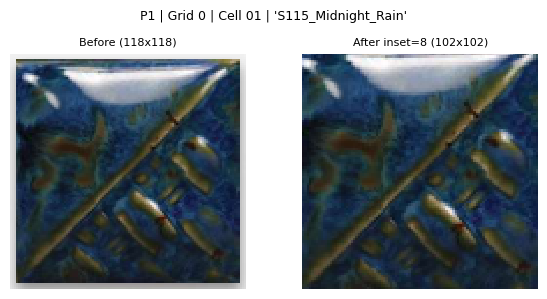

  Saved: S115_Midnight_Rain.png


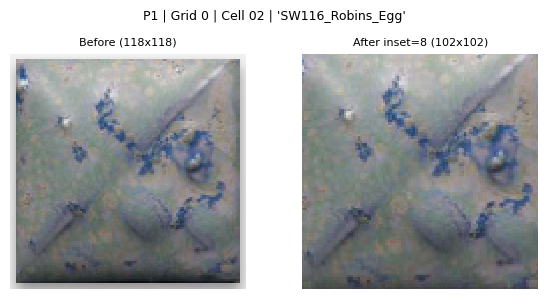

  Saved: SW116_Robins_Egg.png


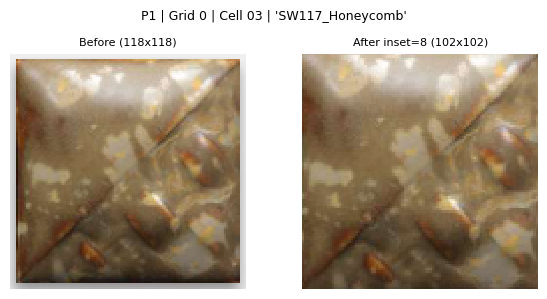

  Saved: SW117_Honeycomb.png


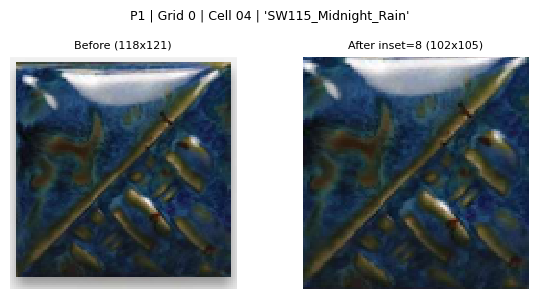

  Saved: SW115_Midnight_Rain.png


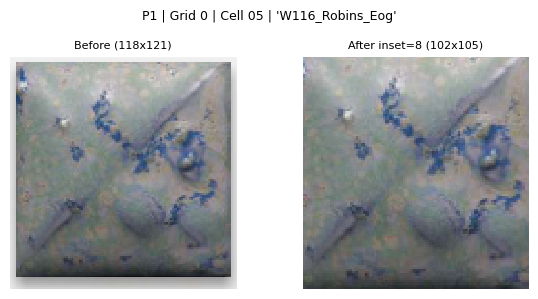

  Saved: W116_Robins_Eog.png


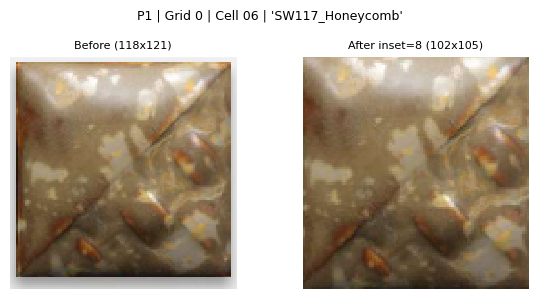

  Saved: SW117_Honeycomb.png


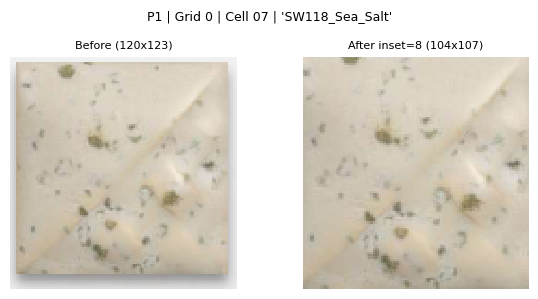

  Saved: SW118_Sea_Salt.png


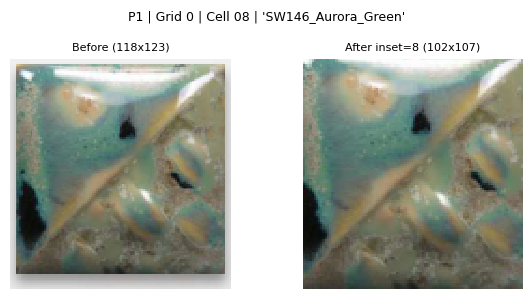

  Saved: SW146_Aurora_Green.png


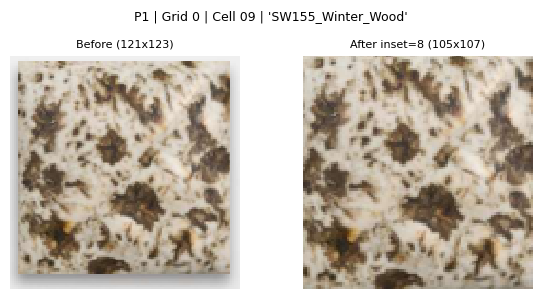

  Saved: SW155_Winter_Wood.png


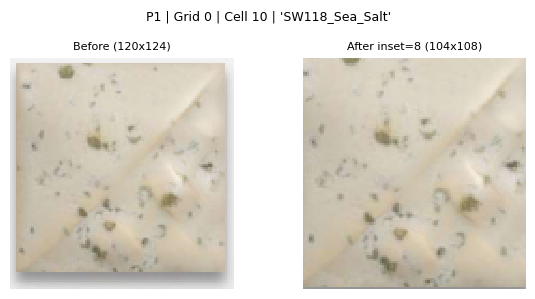

  Saved: SW118_Sea_Salt.png


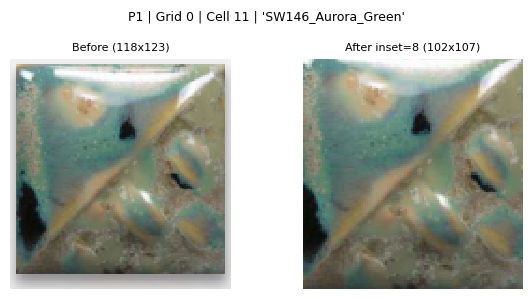

  Saved: SW146_Aurora_Green.png


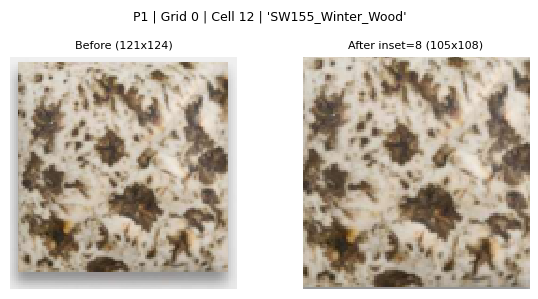

  Saved: SW155_Winter_Wood.png


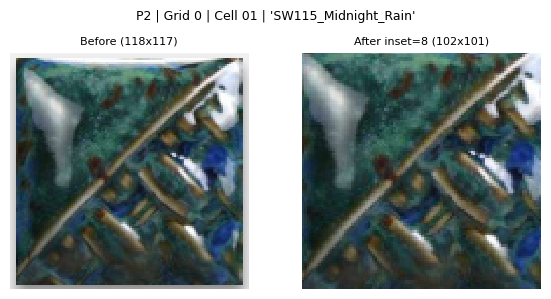

  Saved: SW115_Midnight_Rain.png


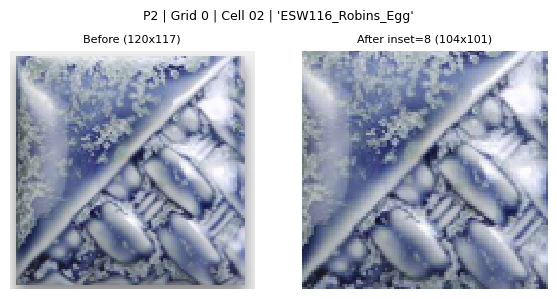

  Saved: ESW116_Robins_Egg.png


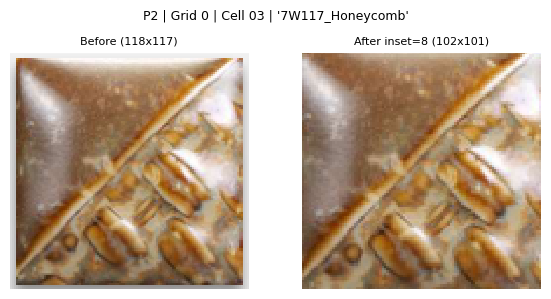

  Saved: 7W117_Honeycomb.png


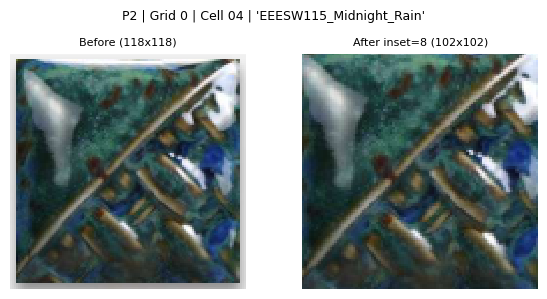

  Saved: EEESW115_Midnight_Rain.png


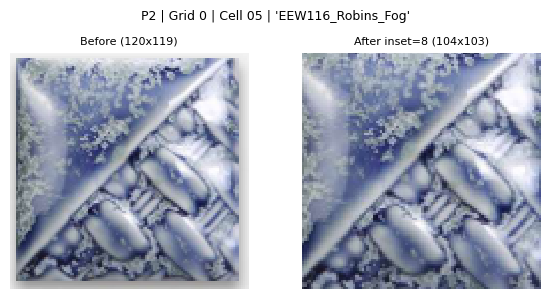

  Saved: EEW116_Robins_Fog.png


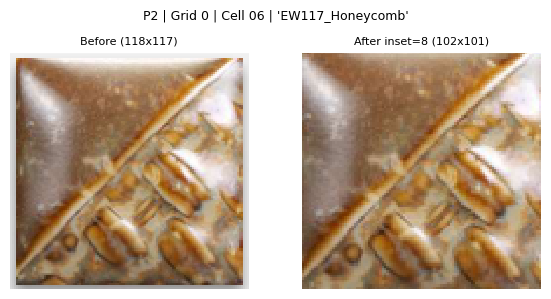

  Saved: EW117_Honeycomb.png


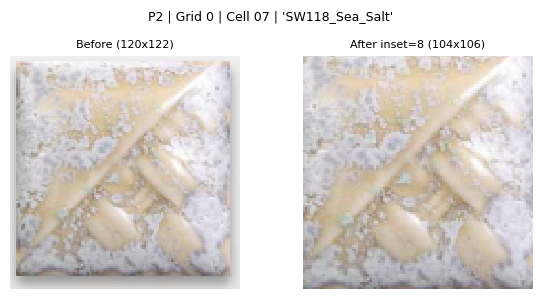

  Saved: SW118_Sea_Salt.png


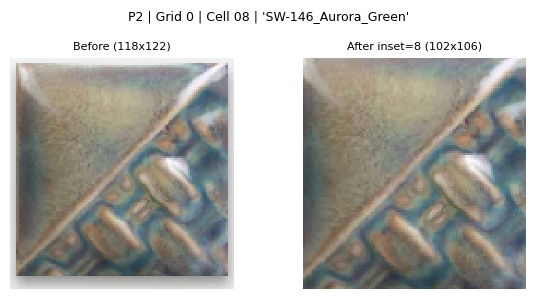

  Saved: SW-146_Aurora_Green.png


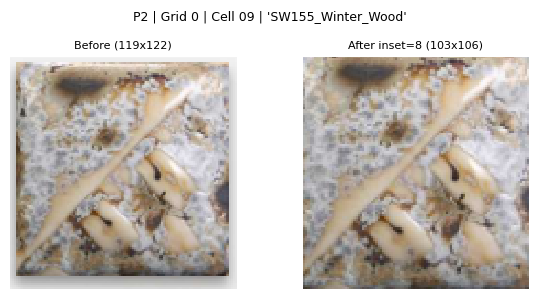

  Saved: SW155_Winter_Wood.png


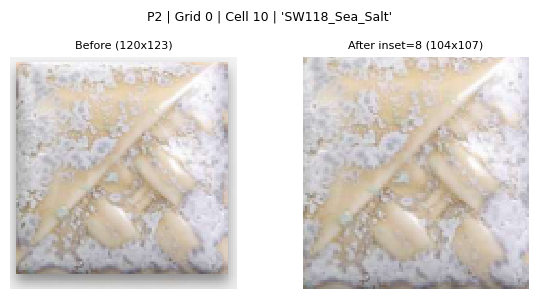

  Saved: SW118_Sea_Salt.png


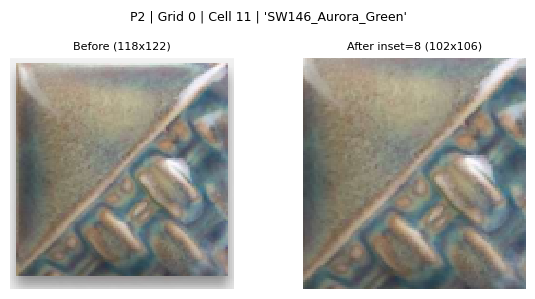

  Saved: SW146_Aurora_Green.png


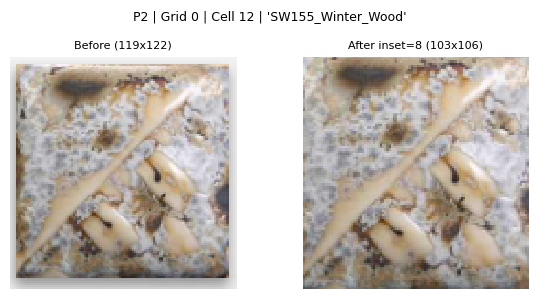

  Saved: SW155_Winter_Wood.png

Total swatches detected : 24
Total files saved       : 14
Collisions (overwritten): 10
Expected vs actual gap  : 10

Collision detail:
  ⚠️  P1 | Grid 0 | Cell 06 — 'SW117_Honeycomb.png' already exists, overwriting
  ⚠️  P1 | Grid 0 | Cell 10 — 'SW118_Sea_Salt.png' already exists, overwriting
  ⚠️  P1 | Grid 0 | Cell 11 — 'SW146_Aurora_Green.png' already exists, overwriting
  ⚠️  P1 | Grid 0 | Cell 12 — 'SW155_Winter_Wood.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 01 — 'SW115_Midnight_Rain.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 07 — 'SW118_Sea_Salt.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 09 — 'SW155_Winter_Wood.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 10 — 'SW118_Sea_Salt.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 11 — 'SW146_Aurora_Green.png' already exists, overwriting
  ⚠️  P2 | Grid 0 | Cell 12 — 'SW155_Winter_Wood.png' already exists, overwriting
Saved to /content/dr

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

INSET = 8
original_filename = os.path.splitext(os.path.basename(uploaded_file))[0]
SAVE_DIR = f"/content/drive/MyDrive/glaze/swatches/type_1_new/{original_filename}"
os.makedirs(SAVE_DIR, exist_ok=True)

saved = 0
overwritten = 0
total_swatches = 0
collision_log = []

for page_number, grid_idx, cell_num, cell in all_cells:
    cell_h, cell_w = cell.shape[:2]

    sy1 = int(cell_h * SWATCH_TOP)
    sy2 = int(cell_h * SWATCH_BOTTOM)
    sx1 = int(cell_w * SWATCH_LEFT)
    sx2 = int(cell_w * SWATCH_RIGHT)
    corner = cell[sy1:sy2, sx1:sx2]

    ty1 = int(cell_h * TEXT_TOP)
    ty2 = int(cell_h * TEXT_BOTTOM)
    tx1 = int(cell_w * TEXT_LEFT)
    tx2 = int(cell_w * TEXT_RIGHT)
    text_region = cell[ty1:ty2, tx1:tx2]

    ocr_text = pytesseract.image_to_string(
        Image.fromarray(text_region),
        config="--psm 6"
    ).strip()

    swatches, _ = detect_swatches_in_cell(corner)

    for idx, (x, y, w, h, variance) in enumerate(swatches):
        total_swatches += 1

        swatch_before = corner[y:y+h, x:x+w]
        swatch_after  = corner[y+INSET:y+h-INSET, x+INSET:x+w-INSET]

        clean_name = ocr_text.strip().replace(" ", "_").replace("/", "-").replace("\\", "-")
        clean_name = "".join(c for c in clean_name if c.isalnum() or c in "_-")
        if not clean_name:
            clean_name = f"page{page_number:02d}_grid{grid_idx}_cell{cell_num:02d}_unknown"

        filename = f"{clean_name}_{idx+1}.png" if len(swatches) > 1 else f"{clean_name}.png"
        full_path = os.path.join(SAVE_DIR, filename)

        if os.path.exists(full_path):
            overwritten += 1
            collision_log.append(f"  ⚠️  P{page_number} | Grid {grid_idx} | Cell {cell_num:02d} — '{filename}' already exists, overwriting")

        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(swatch_before, interpolation="nearest")
        axes[0].set_title(f"Before ({swatch_before.shape[1]}x{swatch_before.shape[0]})", fontsize=8)
        axes[0].axis("off")
        axes[1].imshow(swatch_after, interpolation="nearest")
        axes[1].set_title(f"After inset={INSET} ({swatch_after.shape[1]}x{swatch_after.shape[0]})", fontsize=8)
        axes[1].axis("off")
        plt.suptitle(f"P{page_number} | Grid {grid_idx} | Cell {cell_num:02d} | '{clean_name}'", fontsize=9)
        plt.tight_layout()
        plt.show()

        Image.fromarray(swatch_after).save(full_path)
        saved += 1
        print(f"  Saved: {filename}")

print(f"\n{'='*50}")
print(f"Total swatches detected : {total_swatches}")
print(f"Total files saved       : {len(os.listdir(SAVE_DIR))}")
print(f"Collisions (overwritten): {overwritten}")
print(f"Expected vs actual gap  : {total_swatches - len(os.listdir(SAVE_DIR))}")
if collision_log:
    print(f"\nCollision detail:")
    for log in collision_log:
        print(log)
print(f"{'='*50}")
print(f"Saved to {SAVE_DIR}")